# Siamese ResNet18 — Triplet Loss Training (v2)

Three-way evaluation: **train** / **val** (model selection) / **golden** (unseen test set).

**Flow**:
1. Baseline metrics on val + golden (pretrained ImageNet weights)
2. Train with val for model selection (best checkpoint by val loss)
3. Final evaluation of best model on both val + golden
4. All metrics logged to Weights & Biases

In [1]:
import sys, json, csv, random, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import gc
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import wandb
from dotenv import load_dotenv
import os
# ===============================
# Configuration: Select Room
# ===============================
ROOM = "bedrooms"  # Options: "bedrooms", "living_rooms"

# paths
NOTEBOOK_DIR = Path().cwd()
BASE_DIR = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == "ml" else NOTEBOOK_DIR
while not (BASE_DIR / "data").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

TRIPLET_DIR = BASE_DIR / "data" / "ml_data" / ROOM / "triplets_v3"
IMAGE_DIR   = BASE_DIR / "data" / "total" / ROOM
MODEL_DIR   = BASE_DIR / "data" / "ml_data" / ROOM / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(BASE_DIR / "src" / "ml"))
from model import SiameseResnet18

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"BASE_DIR: {BASE_DIR}")
print(f"Room:     {ROOM}")
print(f"Device:   {DEVICE}")
print(f"Images:   {sum(1 for _ in IMAGE_DIR.rglob('*.jpg'))} jpg files")

# Verify v2 triplet files exist
for f in ["train_triplets.csv", "val_triplets.csv", "golden_triplets.csv"]:
    p = TRIPLET_DIR / f
    assert p.exists(), f"Missing {p} — run build_triplets_v2.py first"
print("Triplet files (v2): OK")

BASE_DIR: /teamspace/studios/this_studio/full_new_thesis_v2
Room:     bedrooms
Device:   cuda
Images:   2662 jpg files
Triplet files (v2): OK


In [2]:
load_dotenv()
API_KEY_WANDB = os.getenv("API_KEY_WANBD")
wandb.login(key=API_KEY_WANDB)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /teamspace/studios/this_studio/.netrc
wandb: Currently logged in as: strus-pn (strus-pn-ukrainian-catholic-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Configuration

In [3]:
CFG = {
    "embedding_dim": 128,
    "margin": 1,
    "epochs": 30,
    "batch_size": 64,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "backbone_lr_factor": 0.1,
    "warmup_epochs": 2,
    "img_size": 224,
    "num_workers": 4,
    "plateau_factor": 0.25,         # halve LR on plateau
    "plateau_patience": 4,         # wait 4 epochs before reducing
    "plateau_min_lr": 1e-6,
    "recall_k_values": [1, 2, 3, 4, 5],         # R@K vs per-pair hard negatives (max ~5)
    "scene_recall_k_values": [5, 10, 15, 20, 25, 30], # R@K over the full test-set gallery
    "seed": 42,
}

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(CFG["seed"])

## 2. Dataset

In [4]:
class TripletDataset(Dataset):

    def __init__(self, csv_path: Path, image_root: Path, transform=None):
        self.image_root = image_root
        self.transform = transform
        self.triplets = []
        with open(csv_path, newline="", encoding="utf-8") as f:
            for row in csv.DictReader(f):
                self.triplets.append((
                    (row["anchor_id"],   row["anchor_category"]),
                    (row["positive_id"], row["positive_category"]),
                    (row["negative_id"], row["negative_category"]),
                ))

        # Pre-load and pre-resize all unique images into RAM
        size = (CFG["img_size"], CFG["img_size"])
        unique_paths = {
            image_root / cat / f"{fid}.jpg"
            for triplet in self.triplets
            for fid, cat in triplet
        }
        print(f"Pre-loading {len(unique_paths)} unique images at {size[0]}px into RAM ...", end=" ", flush=True)
        self._cache: dict[Path, Image.Image] = {}
        for p in unique_paths:
            self._cache[p] = Image.open(p).convert("RGB").resize(size, Image.BILINEAR)
        print("done.")

    def _load_image(self, furn_id: str, category: str) -> Image.Image:
        path = self.image_root / category / f"{furn_id}.jpg"
        return self._cache[path]

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        (a_id, a_cat), (p_id, p_cat), (n_id, n_cat) = self.triplets[idx]
        anchor   = self._load_image(a_id, a_cat)
        positive = self._load_image(p_id, p_cat)
        negative = self._load_image(n_id, n_cat)
        if self.transform:
            anchor   = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)
        return anchor, positive, negative


train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Three datasets: train (augmented), val (no aug), golden (no aug)
train_ds  = TripletDataset(TRIPLET_DIR / "train_triplets.csv",  IMAGE_DIR, train_tf)
val_ds    = TripletDataset(TRIPLET_DIR / "val_triplets.csv",    IMAGE_DIR, val_tf)
golden_ds = TripletDataset(TRIPLET_DIR / "golden_triplets.csv", IMAGE_DIR, val_tf)

train_dl  = DataLoader(train_ds,  batch_size=CFG["batch_size"], shuffle=True,
                       num_workers=0, pin_memory=True, drop_last=True)
val_dl    = DataLoader(val_ds,    batch_size=CFG["batch_size"], shuffle=False,
                       num_workers=0, pin_memory=True)
golden_dl = DataLoader(golden_ds, batch_size=CFG["batch_size"], shuffle=False,
                       num_workers=0, pin_memory=True)

print(f"Train:  {len(train_ds):,} triplets  ({len(train_dl)} batches)")
print(f"Val:    {len(val_ds):,} triplets  ({len(val_dl)} batches)")
print(f"Golden: {len(golden_ds):,} triplets  ({len(golden_dl)} batches)")

Pre-loading 2078 unique images at 224px into RAM ... done.
Pre-loading 403 unique images at 224px into RAM ... done.
Pre-loading 664 unique images at 224px into RAM ... done.
Train:  26,580 triplets  (415 batches)
Val:    4,515 triplets  (71 batches)
Golden: 7,825 triplets  (123 batches)


## 3. Model, Loss & Optimizer

In [5]:
model = SiameseResnet18(embedding_dim=CFG["embedding_dim"], pretrained=True).to(DEVICE)

criterion = nn.TripletMarginLoss(margin=CFG["margin"], p=2)

# Differential LR: backbone trains slower, embedding head trains faster
optimizer = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": CFG["lr"] * CFG["backbone_lr_factor"]},
    {"params": model.embedding.parameters(), "lr": CFG["lr"]},
], weight_decay=CFG["weight_decay"])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CFG["plateau_factor"],
    patience=CFG["plateau_patience"],
    min_lr=CFG["plateau_min_lr"]
)


total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total, {trainable:,} trainable")

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False  # don't stop
        self.counter += 1
        return self.counter >= self.patience  # stop if True

Parameters: 11,341,248 total, 11,341,248 trainable


## 4. Evaluation Functions

In [6]:
F = torch.nn.functional

@torch.no_grad()
def _eval_pass(model, dataloader, device):
    model.eval()
    a_list, p_list, n_list = [], [], []
    total_loss = 0.0
    n = 0
    for anchor, positive, negative in dataloader:
        imgs = torch.cat([anchor, positive, negative], dim=0).to(device)
        embs = model(imgs)
        a, p, ne = embs.chunk(3)
        a_list.append(a.cpu())
        p_list.append(p.cpu())
        n_list.append(ne.cpu())
        total_loss += criterion(a, p, ne).item() * anchor.size(0)
        n += anchor.size(0)
    a_embs = torch.cat(a_list)
    p_embs = torch.cat(p_list)
    n_embs = torch.cat(n_list)
    pos_d = F.pairwise_distance(a_embs, p_embs).numpy()
    neg_d = F.pairwise_distance(a_embs, n_embs).numpy()
    return a_embs, p_embs, n_embs, pos_d, neg_d, total_loss / max(n, 1)


def distance_metrics(pos_d, neg_d):
    correct = (neg_d > pos_d).sum()
    return {
        "triplet_accuracy": float(correct / len(pos_d)),
        "margin_satisfied": float(((neg_d - pos_d) > CFG["margin"]).sum() / len(pos_d)),
        "pos_dist_mean": float(pos_d.mean()),
        "pos_dist_std":  float(pos_d.std()),
        "neg_dist_mean": float(neg_d.mean()),
        "neg_dist_std":  float(neg_d.std()),
        "dist_gap_mean": float((neg_d - pos_d).mean()),
    }


def recall_at_k(a_embs, p_embs, n_embs, k_values, csv_path):
    with open(csv_path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))

    pair_groups = defaultdict(list)
    for i, row in enumerate(rows):
        pair_groups[(row["anchor_id"], row["positive_id"])].append(i)

    ranks = []
    for indices in pair_groups.values():
        a_emb = a_embs[indices[0]]
        p_emb = p_embs[indices[0]]
        d_pos = F.pairwise_distance(a_emb.unsqueeze(0), p_emb.unsqueeze(0)).item()
        neg_dists = [
            F.pairwise_distance(a_embs[i].unsqueeze(0), n_embs[i].unsqueeze(0)).item()
            for i in indices
        ]
        rank = 1 + sum(1 for d in neg_dists if d < d_pos)
        ranks.append(rank)

    ranks = np.array(ranks)
    return {f"recall@{k}": float((ranks <= k).mean()) for k in k_values}


def mean_reciprocal_rank(a_embs, p_embs, n_embs, csv_path):
    with open(csv_path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))

    pair_groups = defaultdict(list)
    for i, row in enumerate(rows):
        pair_groups[(row["anchor_id"], row["positive_id"])].append(i)

    aps = []
    for indices in pair_groups.values():
        a_emb = a_embs[indices[0]]
        p_emb = p_embs[indices[0]]
        d_pos = F.pairwise_distance(a_emb.unsqueeze(0), p_emb.unsqueeze(0)).item()
        neg_dists = [
            F.pairwise_distance(a_embs[i].unsqueeze(0), n_embs[i].unsqueeze(0)).item()
            for i in indices
        ]
        rank = 1 + sum(1 for d in neg_dists if d < d_pos)
        aps.append(1.0 / rank)

    return {"MRR": float(np.mean(aps)), "num_pairs": len(aps)}


def scene_retrieval_recall(a_embs, p_embs, n_embs, k_values, csv_path):
    with open(csv_path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))

    item_to_emb = {}
    scene_to_items = defaultdict(set)
    item_to_scene = {}

    col_map = [
        ("anchor_id",   "anchor_scene",   a_embs),
        ("positive_id", "positive_scene", p_embs),
        ("negative_id", "negative_scene", n_embs),
    ]
    for i, row in enumerate(rows):
        for id_col, scene_col, emb_tensor in col_map:
            fid = row[id_col]
            scene = row[scene_col]
            if fid not in item_to_emb:
                item_to_emb[fid] = emb_tensor[i]
            scene_to_items[scene].add(fid)
            item_to_scene[fid] = scene

    all_ids = list(item_to_emb.keys())
    gallery = torch.stack([item_to_emb[fid] for fid in all_ids])  # [N, D]
    id_to_idx = {fid: idx for idx, fid in enumerate(all_ids)}
    max_k = max(k_values)

    # FIX: compute distances per query row — never materialise the full [N×N] matrix.
    # Original torch.cdist(gallery, gallery) allocated an [N×N] float32 tensor on
    # every eval call and kept it alive until GC — the single biggest RAM leak.
    # Per-row cdist gives identical results at a tiny fraction of the memory.
    hits = {k: [] for k in k_values}
    seen = set()

    for i, row in enumerate(rows):
        a_id = row["anchor_id"]
        if a_id in seen:
            continue
        seen.add(a_id)

        scene_mates = scene_to_items[item_to_scene[a_id]] - {a_id}
        if not scene_mates:
            continue

        a_idx = id_to_idx[a_id]
        # 1 row vs full gallery — O(N·D) instead of O(N²·D)
        dists = torch.cdist(gallery[a_idx].unsqueeze(0), gallery, p=2).squeeze(0)
        dists[a_idx] = float("inf")  # exclude self
        topk_indices = dists.topk(max_k, largest=False).indices.tolist()

        for k in k_values:
            topk_ids = {all_ids[idx] for idx in topk_indices[:k]}
            hits[k].append(float(bool(topk_ids & scene_mates)))

        del dists  # FIX: free per-query vector immediately

    return {f"scene_recall@{k}": float(np.mean(v)) if v else 0.0 for k, v in hits.items()}


def full_evaluation(model, dataloader, csv_path, device, prefix="", compute_scene_recall=True):
    a_embs, p_embs, n_embs, pos_d, neg_d, loss = _eval_pass(model, dataloader, device)
    metrics = {
        "loss": loss,
        **distance_metrics(pos_d, neg_d),
        **recall_at_k(a_embs, p_embs, n_embs, CFG["recall_k_values"], csv_path),
        **mean_reciprocal_rank(a_embs, p_embs, n_embs, csv_path),
    }
    if compute_scene_recall:
        metrics.update(scene_retrieval_recall(
            a_embs, p_embs, n_embs, CFG["scene_recall_k_values"], csv_path
        ))

    # FIX: delete large stacked embedding tensors once metrics are computed —
    # without this they stay alive for the entire epoch, consuming 100s of MB.
    del a_embs, p_embs, n_embs
    gc.collect()

    if prefix:
        metrics = {f"{prefix}/{k}": v for k, v in metrics.items()}
    return metrics, pos_d, neg_d


## 5. Visualization Helpers

In [7]:
def plot_distance_hist(pos_d, neg_d, title="Distance Distribution"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(pos_d, bins=60, alpha=0.6, label=f"Positive (\u03bc={pos_d.mean():.3f})", color="#2196F3")
    ax.hist(neg_d, bins=60, alpha=0.6, label=f"Negative (\u03bc={neg_d.mean():.3f})", color="#F44336")
    ax.axvline(CFG["margin"], color="k", ls="--", label=f"Margin={CFG['margin']}")
    ax.set_xlabel("L2 Distance"); ax.set_ylabel("Count"); ax.set_title(title)
    ax.legend(); fig.tight_layout()
    return fig


def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(list(epochs), history["train_loss"], "b-", label="Train")
    axes[0].plot(list(epochs), history["val_loss"], "r-", label="Val")
    axes[0].set_title("Triplet Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(list(epochs), history["val_mrr"], "r-", label="Val MRR")
    axes[1].plot(list(epochs), history["val_accuracy"], "g-", label="Val Accuracy")
    axes[1].set_title("Val Metrics"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    axes[1].set_ylim(0, 1.05)

    fig.tight_layout()
    return fig


def print_metrics_table(metrics_dict, title=""):
    """Print a comparison table for multiple metric dicts (e.g. baseline vs trained)."""
    if title:
        print(f"\n{title}")

    # Collect all prefixes
    prefixes = sorted(set(k.split("/")[0] for k in metrics_dict))
    # Collect all metric names (after prefix/)
    all_keys = sorted(set(k.split("/", 1)[1] for k in metrics_dict if "/" in k))

    display_keys = ["loss", "triplet_accuracy", "margin_satisfied",
            "pos_dist_mean", "neg_dist_mean", "dist_gap_mean",
            "recall@1", "recall@2", "recall@3", "recall@4", "recall@5", "MRR",
            "scene_recall@5", "scene_recall@10", "scene_recall@15", "scene_recall@20", "scene_recall@25", "scene_recall@30"]
    display_keys = [k for k in display_keys if k in all_keys]

    header = f"{'Metric':<28}" + "".join(f"{p:>14}" for p in prefixes)
    print("=" * len(header))
    print(header)
    print("-" * len(header))
    for key in display_keys:
        row = f"{key:<28}"
        for p in prefixes:
            val = metrics_dict.get(f"{p}/{key}", 0)
            row += f"{val:>14.4f}"
        print(row)
    print("=" * len(header))

## 6. Pretrained Baseline

Evaluate the ImageNet-pretrained model on **both** val and golden sets before any training.

In [8]:
print("Evaluating baseline on val set ...")
baseline_val, bl_pos_val, bl_neg_val = full_evaluation(
    model, val_dl, TRIPLET_DIR / "val_triplets.csv", DEVICE, prefix="baseline_val"
)

print("Evaluating baseline on golden set ...")
baseline_golden, bl_pos_go, bl_neg_go = full_evaluation(
    model, golden_dl, TRIPLET_DIR / "golden_triplets.csv", DEVICE, prefix="baseline_golden"
)

print_metrics_table({**baseline_val, **baseline_golden}, title="BASELINE (pretrained)")

Evaluating baseline on val set ...


Evaluating baseline on golden set ...

BASELINE (pretrained)
Metric                      baseline_golden  baseline_val
---------------------------------------------------------
loss                                0.9766        0.9787
triplet_accuracy                    0.5815        0.5847
margin_satisfied                    0.0000        0.0000
pos_dist_mean                       0.7265        0.7254
neg_dist_mean                       0.7500        0.7467
dist_gap_mean                       0.0234        0.0213
recall@1                            0.2518        0.2647
recall@2                            0.4268        0.4485
recall@3                            0.6000        0.5991
recall@4                            0.7508        0.7453
recall@5                            0.8780        0.8660
MRR                                 0.4805        0.4898
scene_recall@5                      0.0500        0.0410
scene_recall@10                     0.0827        0.0915
scene_recall@15          

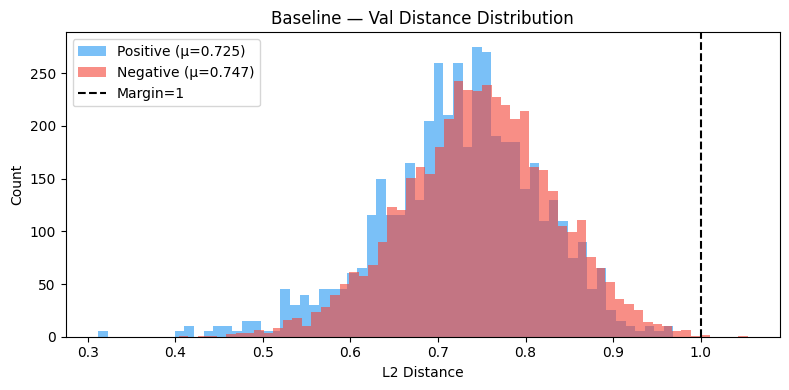

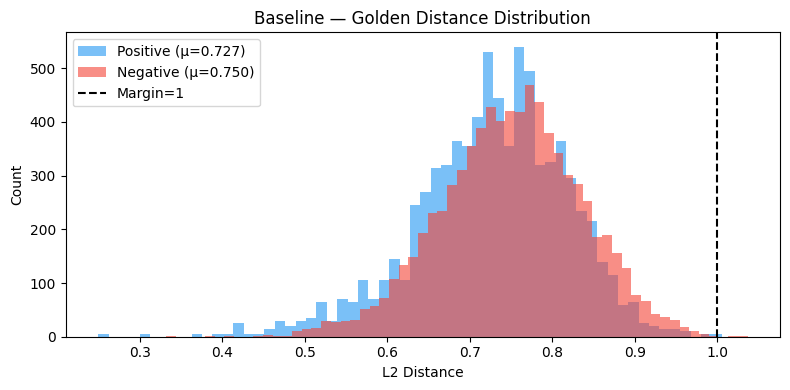

In [9]:
fig = plot_distance_hist(bl_pos_val, bl_neg_val, "Baseline \u2014 Val Distance Distribution")
plt.show()

fig = plot_distance_hist(bl_pos_go, bl_neg_go, "Baseline \u2014 Golden Distance Distribution")
plt.show()

## 7. Training Loop

Model selection by **val loss**. Golden set is never used during training — only at baseline and final evaluation.

In [10]:
run = wandb.init(
    project="furnishings_compatibility",
    name="bedrooms_v3_new_data_resnet18",
    config={**CFG, "room": ROOM, "split_version": "v3_golden"},
    tags=["triplet-loss", "siamese-resnet", "v2", ROOM],
)
wandb.log({**baseline_val, **baseline_golden}, step=0)
print(f"W&B run: {run.url}")

W&B run: https://wandb.ai/strus-pn-ukrainian-catholic-university/furnishings_compatibility/runs/775m7bjg


In [11]:
history = defaultdict(list)
best_val_loss = float('inf')
best_epoch = 0
early_stopping = EarlyStopping(patience=20, min_delta=0)  # early stopping
scaler = torch.amp.GradScaler()


def set_warmup_lr(optimizer, epoch, warmup_epochs, base_lrs):
    """Linearly scale LR from 0 to base during warmup."""
    if epoch <= warmup_epochs:
        scale = epoch / warmup_epochs
        for pg, base_lr in zip(optimizer.param_groups, base_lrs):
            pg["lr"] = base_lr * scale
        return True  # still in warmup
    return False

base_lrs = [CFG["lr"] * CFG["backbone_lr_factor"], CFG["lr"]]  # warmup base LRs


epoch_bar = tqdm(range(1, CFG["epochs"] + 1), desc="Training", unit="epoch")
for epoch in epoch_bar:
    is_warmup = set_warmup_lr(optimizer, epoch, CFG["warmup_epochs"], base_lrs)  # warmup LR scaling

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    n_samples = 0

    # FIX: try/finally ensures batch_bar.close() always runs.
    # Without this, each epoch leaks a tqdm widget into the Jupyter frontend
    # (visible as "Could not render widget-view+json" in logs) — OOM over time.
    batch_bar = tqdm(train_dl, desc=f"Epoch {epoch}/{CFG['epochs']}", leave=False)
    try:
        for anchor, positive, negative in batch_bar:
            imgs = torch.cat([anchor, positive, negative], dim=0).to(DEVICE)
            embs = model(imgs)
            a_emb, p_emb, n_emb = embs.chunk(3)

            loss = criterion(a_emb, p_emb, n_emb)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss += loss.item() * anchor.size(0)
            n_samples += anchor.size(0)
            batch_bar.set_postfix(loss=f"{running_loss/n_samples:.4f}")
    finally:
        batch_bar.close()  # FIX: always close, prevents widget accumulation

    epoch_train_loss = running_loss / n_samples

    # ── Evaluate on Val ───────────────────────────────────────────────────
    val_metrics, _, _ = full_evaluation(
        model, val_dl, TRIPLET_DIR / "val_triplets.csv", DEVICE, prefix="val"
    )

    val_loss = val_metrics["val/loss"]

    # FIX: ReduceLROnPlateau requires val_loss argument; skip during warmup
    # to avoid reducing LR before it has even reached its target value.
    if not is_warmup:  # skip scheduler step during warmup epochs
        scheduler.step(val_loss)  # FIX: was bare scheduler.step() — wrong for ReduceLROnPlateau

    log_dict = {
        "epoch": epoch,
        "train/loss": epoch_train_loss,
        "lr_backbone": optimizer.param_groups[0]["lr"],
        "lr_head": optimizer.param_groups[1]["lr"],
        **val_metrics,
    }
    wandb.log(log_dict, step=epoch)

    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(val_metrics["val/loss"])
    history["val_accuracy"].append(val_metrics["val/triplet_accuracy"])
    history["val_mrr"].append(val_metrics["val/MRR"])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch

        # ── Save locally ──────────────────────────────────────────────────
        ckpt_path = MODEL_DIR / "best_model_v3_resnet18_new_data.pt"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "config": CFG,
        }, ckpt_path)

        # ── Save to W&B ───────────────────────────────────────────────────
        artifact = wandb.Artifact(
            name="best_model_v3_resnet18_new_data",
            type="model",
            metadata={"epoch": epoch, "val_loss": val_loss, "config": CFG},
        )
        artifact.add_file(str(ckpt_path))
        wandb.log_artifact(artifact)
        del artifact  # FIX: explicit delete prevents artifact object accumulation in memory

        marker = " \u2605 best"
    else:
        marker = ""

    epoch_bar.set_postfix(
        loss=f"{epoch_train_loss:.4f}",
        val_acc=f"{val_metrics['val/triplet_accuracy']:.3f}",
        val_loss=f"{val_loss:.3f}",
    )
    tqdm.write(f"Epoch {epoch:>2}/{CFG['epochs']}  "
               f"loss={epoch_train_loss:.4f}  "
               f"val_acc={val_metrics['val/triplet_accuracy']:.3f}  "
               f"val_loss={val_loss:.3f}{marker}")

    # FIX: release CUDA allocator cache + run Python GC after every epoch.
    # Prevents gradual VRAM/RAM growth from tensors the allocator hasn't reclaimed.
    torch.cuda.empty_cache()
    gc.collect()

    # Early stopping check
    if early_stopping.step(val_loss):
        tqdm.write(f"Early stopping triggered — no improvement for {early_stopping.patience} epochs")
        break

# ── Save final locally + W&B ──────────────────────────────────────────────
final_path = MODEL_DIR / "final_model_v3_resnet18_new_data.pt"
torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "config": CFG}, final_path)

artifact = wandb.Artifact(
    name="final_model_v3_resnet18_new_data",
    type="model",
    metadata={"epoch": epoch, "config": CFG},
)
artifact.add_file(str(final_path))
wandb.log_artifact(artifact)
del artifact  # FIX: explicit delete

print(f"\nDone. Best val_loss={best_val_loss:.4f} at epoch {best_epoch}")


Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch  1/30  loss=0.6778  val_acc=0.774  val_loss=0.593 ★ best


Epoch 2/30:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch  2/30  loss=0.3961  val_acc=0.785  val_loss=0.534 ★ best


...

Epoch 28/30  loss=0.0714  val_acc=0.800  val_loss=0.500


Epoch 29/30:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch 29/30  loss=0.0707  val_acc=0.798  val_loss=0.502


Epoch 30/30:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch 30/30  loss=0.0708  val_acc=0.798  val_loss=0.502

Done. Best val_loss=0.4991 at epoch 20


## 8. Training Curves

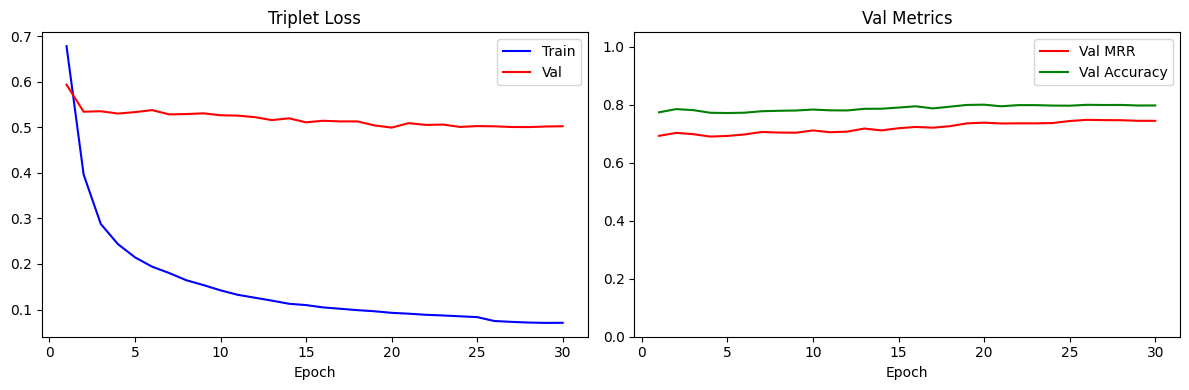

In [12]:
fig = plot_training_curves(history)
wandb.log({"training_curves": wandb.Image(fig)})
plt.show()

## 9. Final Evaluation (Best Checkpoint)

Load the best model and evaluate on **both** val and golden sets. This is the key result — golden metrics show generalization to unseen data.

In [13]:
ckpt = torch.load(MODEL_DIR / "best_model_v3_resnet18_new_data.pt", map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}\n")

# Final val
print("Evaluating best model on val set ...")
final_val, fin_pos_val, fin_neg_val = full_evaluation(
    model, val_dl, TRIPLET_DIR / "val_triplets.csv", DEVICE, prefix="final_val"
)

# Final golden
print("Evaluating best model on golden set ...")
final_golden, fin_pos_go, fin_neg_go = full_evaluation(
    model, golden_dl, TRIPLET_DIR / "golden_triplets.csv", DEVICE, prefix="final_golden"
)

# Log to WandB
wandb.log({**final_val, **final_golden})

Loaded best checkpoint from epoch 20

Evaluating best model on val set ...
Evaluating best model on golden set ...


In [14]:
# ── Comparison table: Baseline vs Trained, Val vs Golden ──────────────────
METRIC_KEYS = ["loss", "triplet_accuracy", "margin_satisfied",
            "pos_dist_mean", "neg_dist_mean", "dist_gap_mean",
            "recall@1", "recall@2", "recall@3", "recall@4", "recall@5", "MRR",
            "scene_recall@5", "scene_recall@10", "scene_recall@15", "scene_recall@20", "scene_recall@25", "scene_recall@30"]

print("=" * 90)
print(f"{'Metric':<28} {'BL Val':>10} {'BL Gold':>10} {'Tr Val':>10} {'Tr Gold':>10} {'D Val':>10} {'D Gold':>10}")
print("-" * 90)
for key in METRIC_KEYS:
    bl_v = baseline_val.get(f"baseline_val/{key}", 0)
    bl_g = baseline_golden.get(f"baseline_golden/{key}", 0)
    fn_v = final_val.get(f"final_val/{key}", 0)
    fn_g = final_golden.get(f"final_golden/{key}", 0)
    d_v = fn_v - bl_v
    d_g = fn_g - bl_g
    print(f"{key:<28} {bl_v:>10.4f} {bl_g:>10.4f} {fn_v:>10.4f} {fn_g:>10.4f} {d_v:>+10.4f} {d_g:>+10.4f}")
print("=" * 90)

Metric                           BL Val    BL Gold     Tr Val    Tr Gold      D Val     D Gold
------------------------------------------------------------------------------------------
loss                             0.9787     0.9766     0.4991     0.4743    -0.4796    -0.5023
triplet_accuracy                 0.5847     0.5815     0.8004     0.8152    +0.2157    +0.2337
margin_satisfied                 0.0000     0.0000     0.3604     0.3641    +0.3604    +0.3641
pos_dist_mean                    0.7254     0.7265     0.7744     0.7700    +0.0490    +0.0435
neg_dist_mean                    0.7467     0.7500     1.3959     1.4120    +0.6492    +0.6620
dist_gap_mean                    0.0213     0.0234     0.6215     0.6420    +0.6002    +0.6185
recall@1                         0.2647     0.2518     0.6080     0.6288    +0.3433    +0.3770
recall@2                         0.4485     0.4268     0.7386     0.7642    +0.2901    +0.3374
recall@3                         0.5991     0.6000    

## 10. Distance Distribution Plots

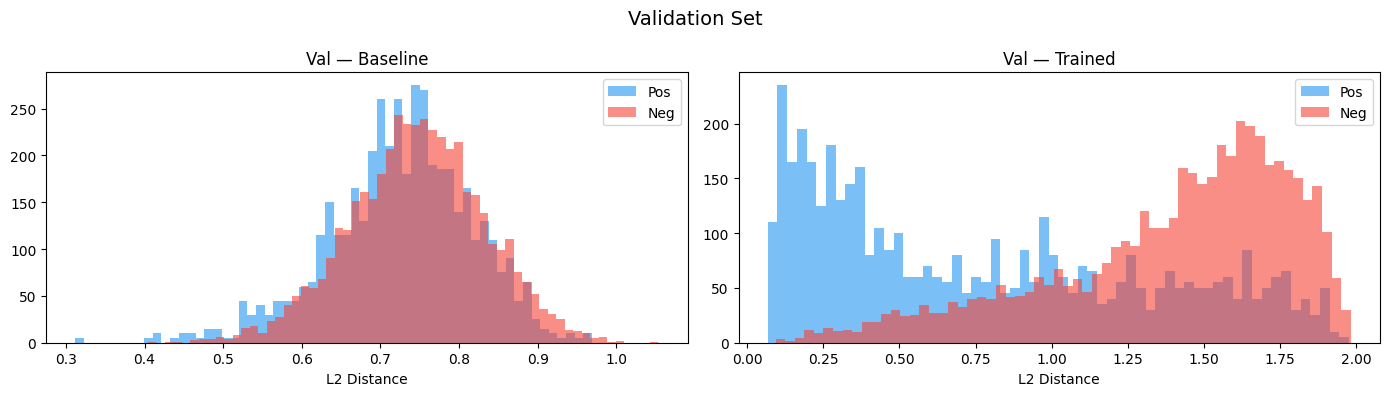

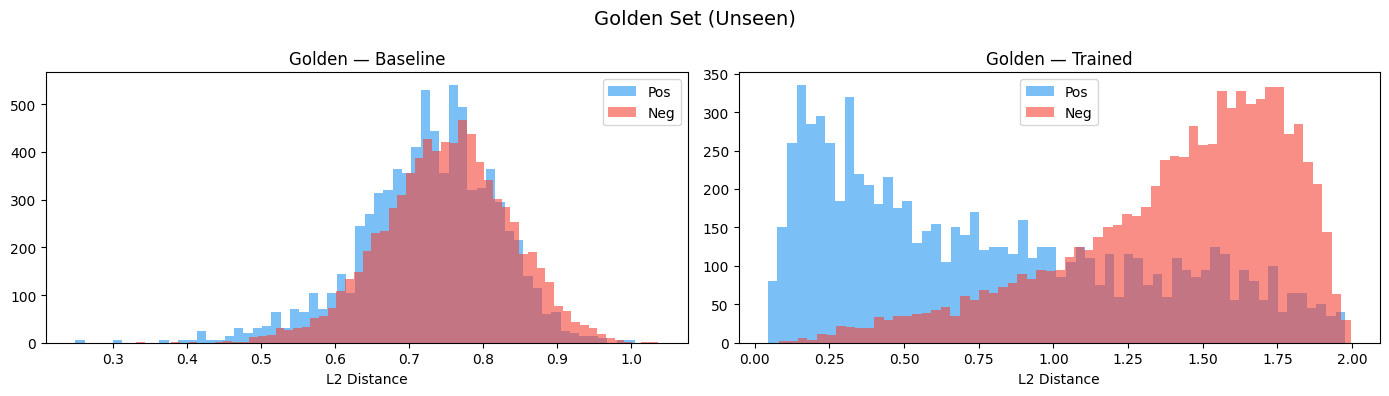

In [15]:
# Val: baseline vs trained
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(bl_pos_val, bins=60, alpha=0.6, label="Pos", color="#2196F3")
axes[0].hist(bl_neg_val, bins=60, alpha=0.6, label="Neg", color="#F44336")
axes[0].set_title("Val \u2014 Baseline"); axes[0].set_xlabel("L2 Distance"); axes[0].legend()
axes[1].hist(fin_pos_val, bins=60, alpha=0.6, label="Pos", color="#2196F3")
axes[1].hist(fin_neg_val, bins=60, alpha=0.6, label="Neg", color="#F44336")
axes[1].set_title("Val \u2014 Trained"); axes[1].set_xlabel("L2 Distance"); axes[1].legend()
fig.suptitle("Validation Set", fontsize=14)
fig.tight_layout()
wandb.log({"val_baseline_vs_trained": wandb.Image(fig)})
plt.show()

# Golden: baseline vs trained
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(bl_pos_go, bins=60, alpha=0.6, label="Pos", color="#2196F3")
axes[0].hist(bl_neg_go, bins=60, alpha=0.6, label="Neg", color="#F44336")
axes[0].set_title("Golden \u2014 Baseline"); axes[0].set_xlabel("L2 Distance"); axes[0].legend()
axes[1].hist(fin_pos_go, bins=60, alpha=0.6, label="Pos", color="#2196F3")
axes[1].hist(fin_neg_go, bins=60, alpha=0.6, label="Neg", color="#F44336")
axes[1].set_title("Golden \u2014 Trained"); axes[1].set_xlabel("L2 Distance"); axes[1].legend()
fig.suptitle("Golden Set (Unseen)", fontsize=14)
fig.tight_layout()
wandb.log({"golden_baseline_vs_trained": wandb.Image(fig)})
plt.show()

In [16]:
wandb.finish()
print("W&B run finished.")

baseline_golden/MRR,▁
baseline_golden/dist_gap_mean,▁
baseline_golden/loss,▁
baseline_golden/margin_satisfied,▁
baseline_golden/neg_dist_mean,▁
baseline_golden/neg_dist_std,▁
baseline_golden/num_pairs,▁
baseline_golden/pos_dist_mean,▁
baseline_golden/pos_dist_std,▁
baseline_golden/recall@1,▁
+99,...


W&B run finished.
